Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

In [3]:
import pandas as pd

df = pd.read_excel('placementdata.xlsx')
print(df.head())

   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks  Hackerrank  Leetcode  \
0                No         61         79         233        42   
1               Yes         78

PREPROCESSING

In [4]:
from sklearn.preprocessing import LabelEncoder

df = df.drop_duplicates()
df.fillna(df.median(numeric_only=True), inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [5]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,Hackerrank,Leetcode,coding contests,coding score,PlacementStatus
0,1,7.5,1,1,1,65,4.4,0,0,61,79,233,42,6,335,0
1,2,8.9,0,3,2,90,4.0,1,1,78,82,194,164,7,428,1
2,3,7.3,1,2,2,82,4.8,1,0,79,80,170,110,6,340,0
3,4,7.5,1,1,2,85,4.4,1,1,81,80,63,50,2,133,1
4,5,8.3,1,2,2,86,4.5,1,1,74,88,53,85,3,168,1


Split data


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('PlacementStatus', axis=1)  # adjust if name differs
y = df['PlacementStatus']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Decision tree

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=6,          # control overfitting
    min_samples_split=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_split=5, random_state=42)

Decision tree accuracy

In [13]:
from sklearn.metrics import accuracy_score

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.785


Train model

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=300,
                       random_state=42)

Accuracy

In [8]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.808


Confusion Matrix

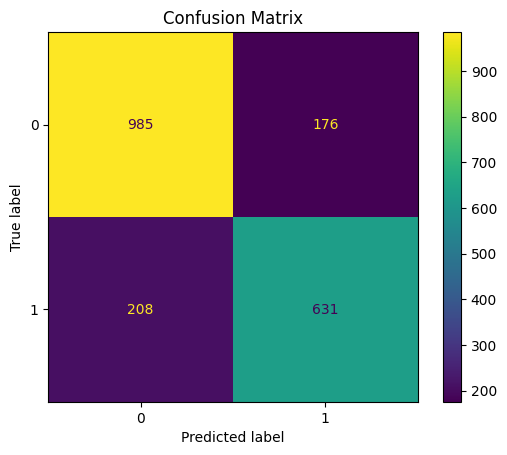

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

ROC CURVE

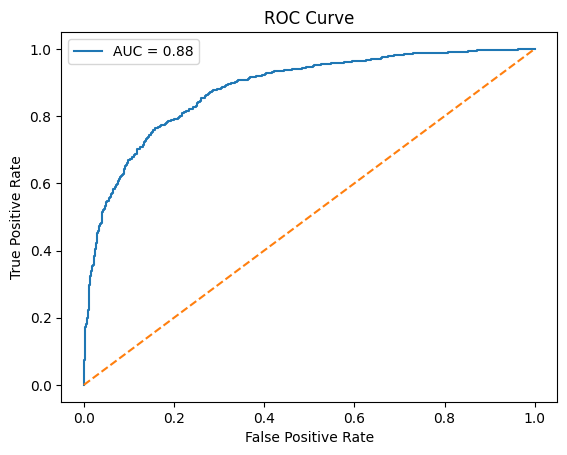

In [10]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()